In [1]:
# Imports
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import json
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

shap.initjs()
print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load Data
model = xgb.Booster()
model.load_model("./models/lambdamart_model.json")

feature_matrix = np.load("./data/feature_matrix.npy")
labels_list = np.load("./data/labels.npy")
feature_names = json.load(open("./data/feature_names.json"))
with open("./data/clean_msmarco.json") as f:
    data = json.load(f)

print(f"Model and data loaded!")
print(f"Feature matrix: {feature_matrix.shape}")

Model and data loaded!
Feature matrix: (39962, 23)


In [3]:
# Compute SHAP Values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(feature_matrix)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (39962, 23)


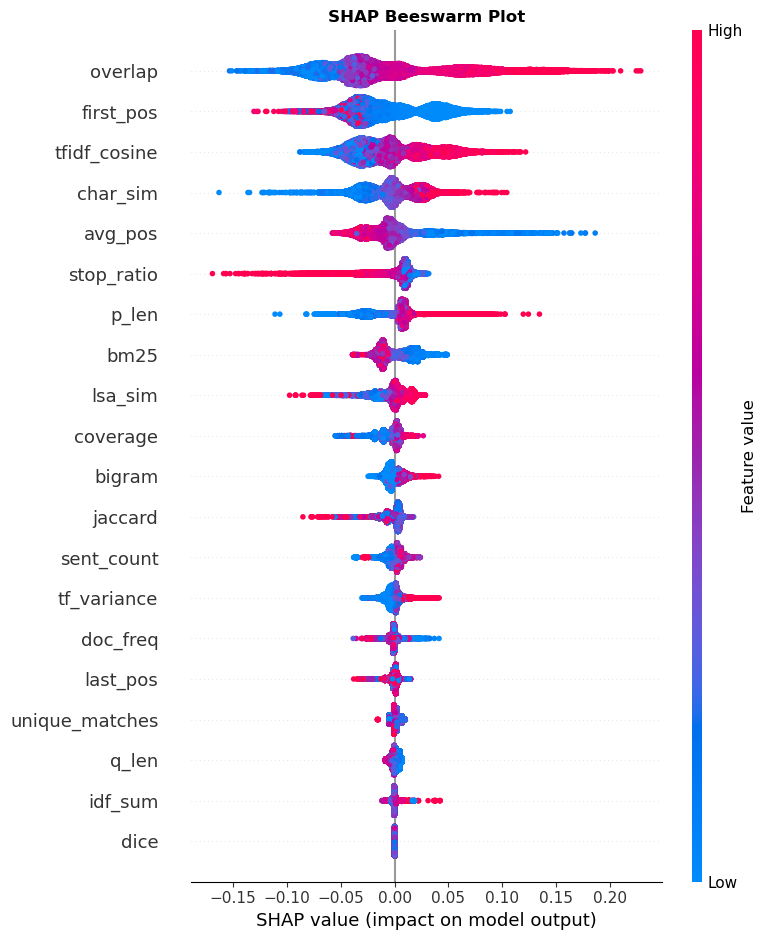

In [4]:
# Beeswarm Plot
shap.summary_plot(shap_values, feature_matrix, feature_names=feature_names, show=False)
plt.title("SHAP Beeswarm Plot", fontweight='bold')
plt.tight_layout()
plt.savefig("./data/shap_beeswarm.png", dpi=150)
plt.show()

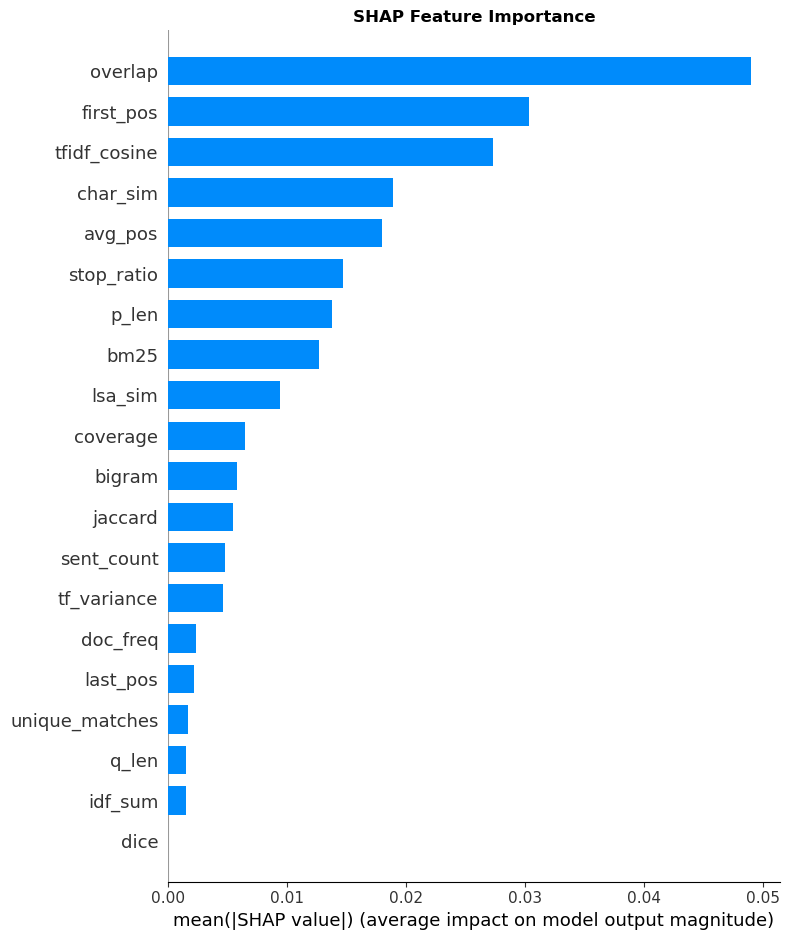

In [5]:
# SHAP Bar Plot
shap.summary_plot(shap_values, feature_matrix, feature_names=feature_names, plot_type="bar", show=False)
plt.title("SHAP Feature Importance", fontweight='bold')
plt.tight_layout()
plt.savefig("./data/shap_bar.png", dpi=150)
plt.show()

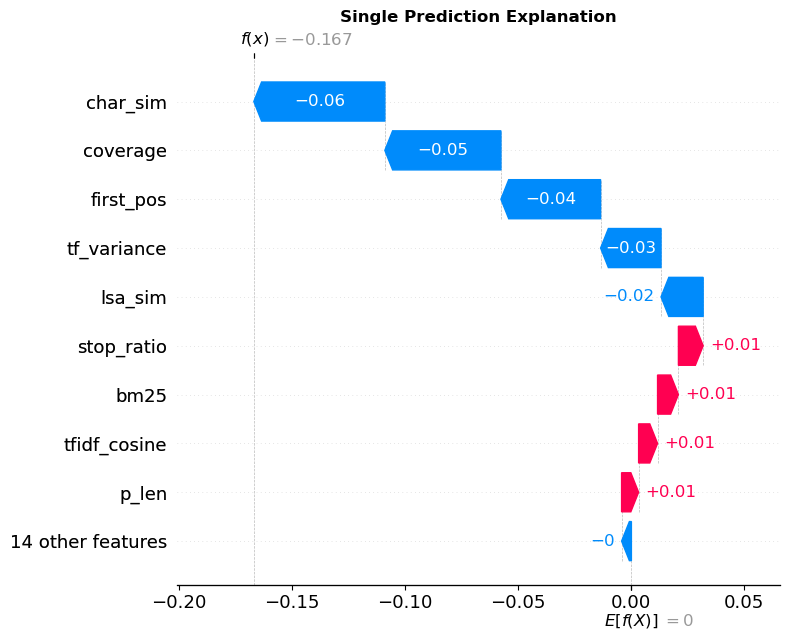

In [7]:
# Waterfall Plot - Single Query Explanation
idx = 0
shap.waterfall_plot(shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    feature_names=feature_names
), show=False)
plt.title("Single Prediction Explanation", fontweight='bold')
plt.tight_layout()
plt.savefig("./data/shap_waterfall.png", dpi=150)
plt.show()

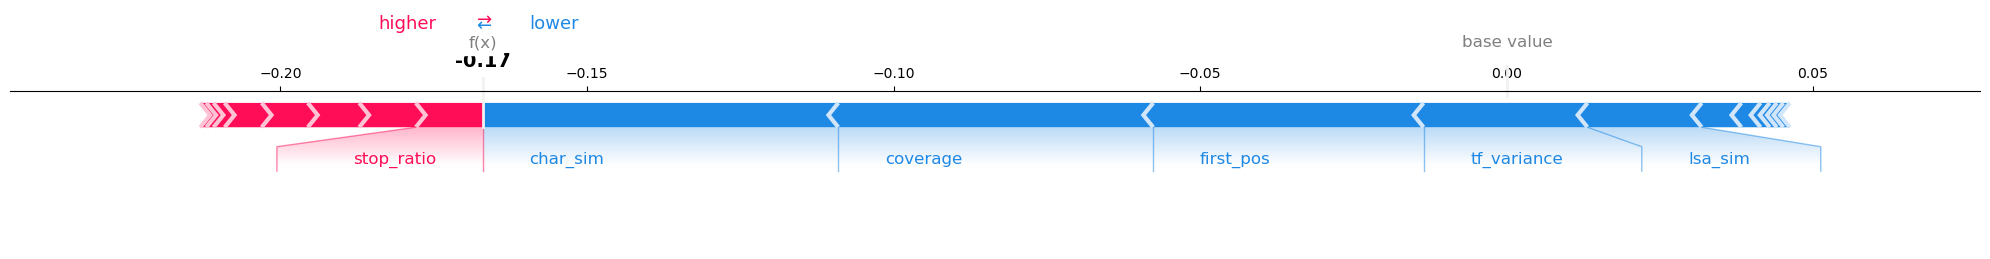

In [8]:
# Force Plot
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    feature_names=feature_names,
    matplotlib=True,
    show=False
)
plt.tight_layout()
plt.savefig("./data/shap_force.png", dpi=150, bbox_inches='tight')
plt.show()

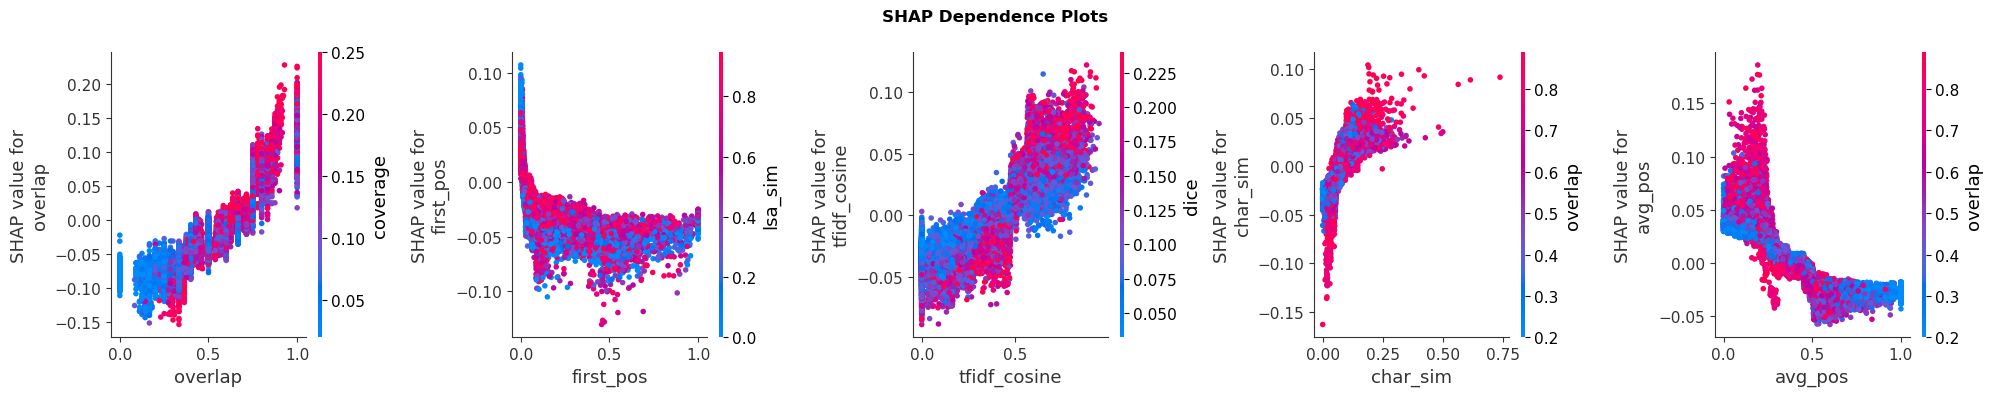

In [9]:
# Dependence Plots for Top 5 Features
top_features = ['overlap', 'first_pos', 'tfidf_cosine', 'char_sim', 'avg_pos']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, feat in enumerate(top_features):
    shap.dependence_plot(feat, shap_values, feature_matrix, 
                        feature_names=feature_names, ax=axes[i], show=False)

plt.suptitle("SHAP Dependence Plots", fontweight='bold')
plt.tight_layout()
plt.savefig("./data/shap_dependence.png", dpi=150)
plt.show()

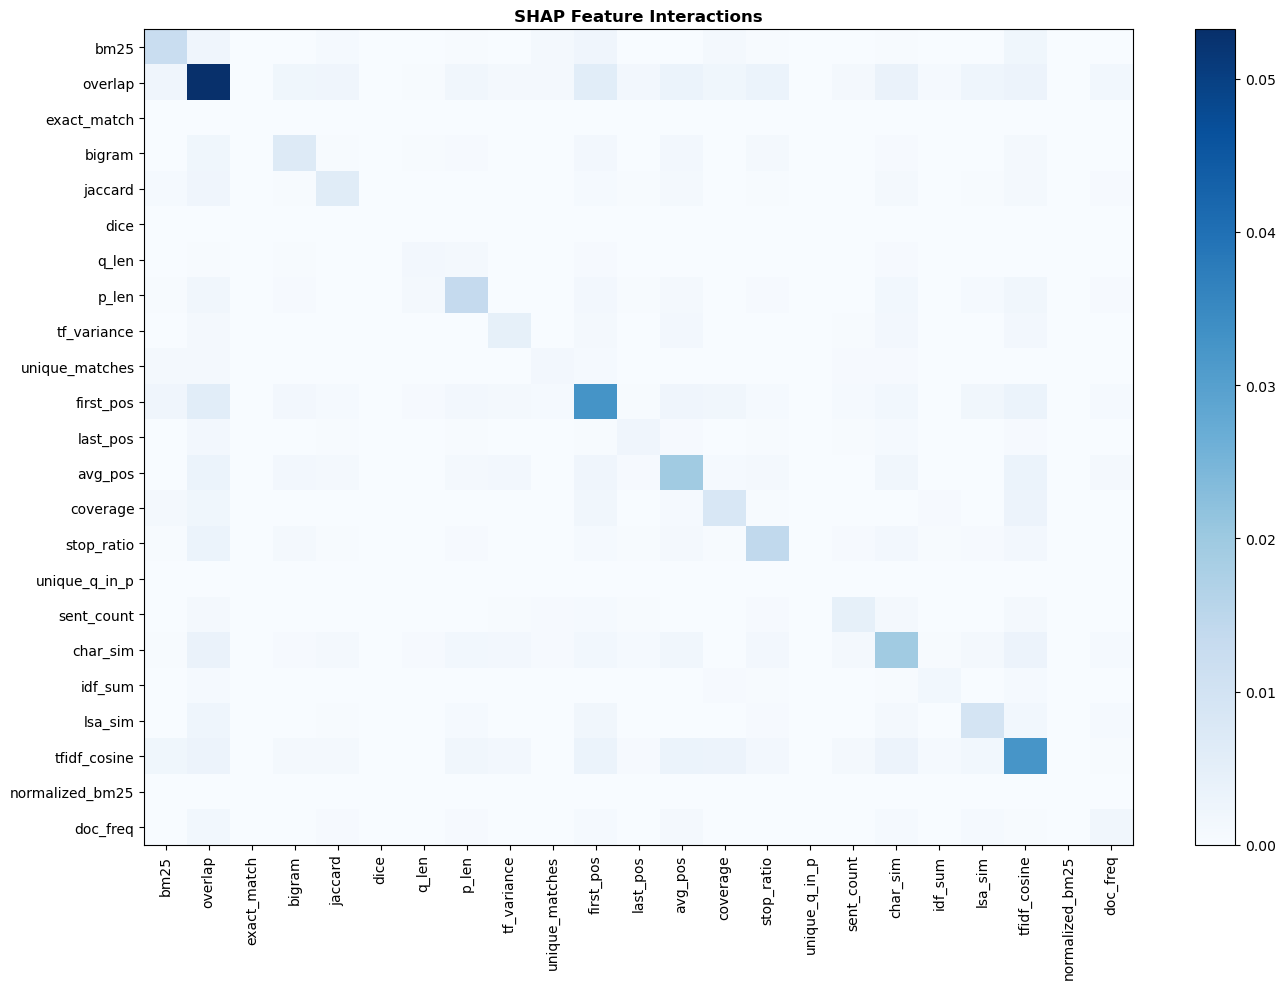

In [10]:
# Feature Interaction Analysis
shap_interaction = explainer.shap_interaction_values(feature_matrix[:500])

interaction_df = pd.DataFrame(
    np.abs(shap_interaction).mean(0),
    index=feature_names, columns=feature_names
)

plt.figure(figsize=(14, 10))
plt.imshow(interaction_df.values, cmap='Blues', aspect='auto')
plt.colorbar()
plt.xticks(range(len(feature_names)), feature_names, rotation=90)
plt.yticks(range(len(feature_names)), feature_names)
plt.title("SHAP Feature Interactions", fontweight='bold')
plt.tight_layout()
plt.savefig("./data/shap_interactions.png", dpi=150)
plt.show()

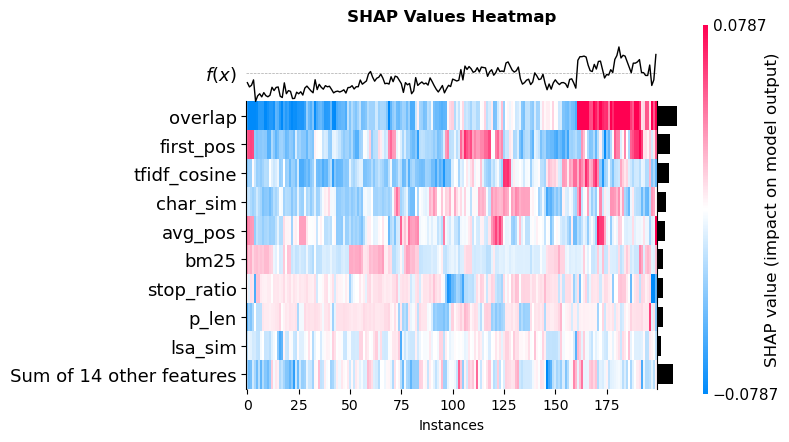

In [11]:
# SHAP Heatmap
shap.plots.heatmap(shap.Explanation(
    values=shap_values[:200],
    base_values=np.full(200, explainer.expected_value),
    feature_names=feature_names
), show=False)
plt.title("SHAP Values Heatmap", fontweight='bold')
plt.tight_layout()
plt.savefig("./data/shap_heatmap.png", dpi=150)
plt.show()

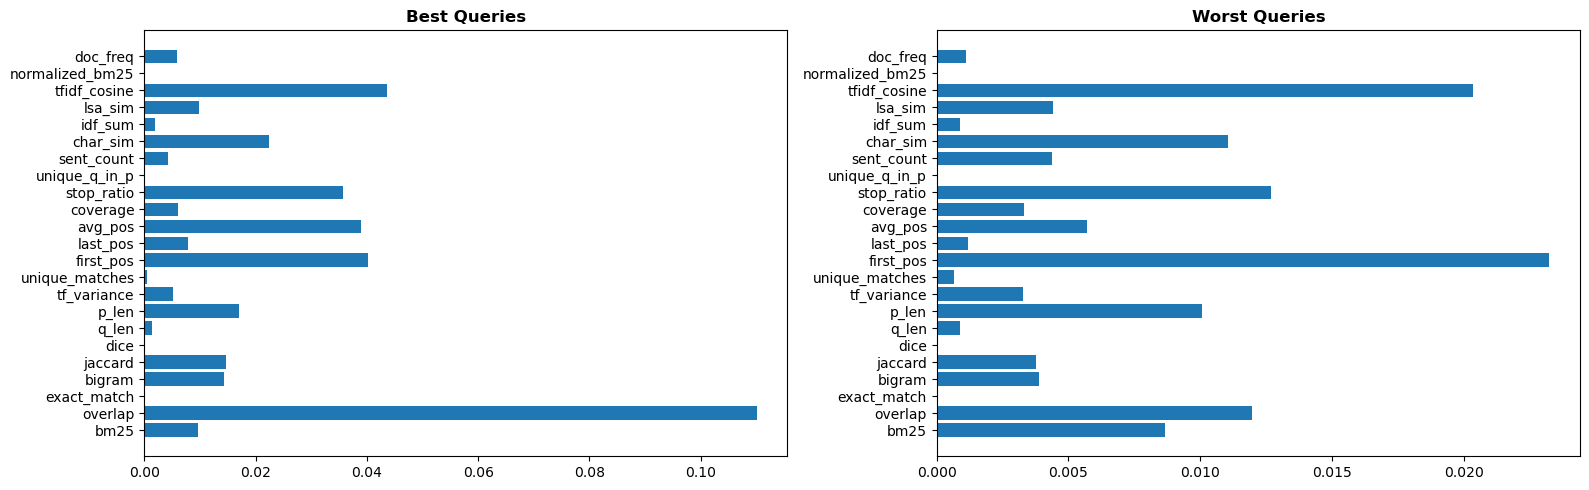

In [12]:
# Best vs Worst Query SHAP Analysis
cumsum = np.cumsum(np.concatenate([[0], [len(d['passages']) for d in data]]))
q_shap = np.array([np.abs(shap_values[cumsum[i]:cumsum[i+1]]).mean(0) for i in range(len(data))])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, idx, title in zip(axes, [q_shap.sum(1).argsort()[-5:], q_shap.sum(1).argsort()[:5]], ['Best Queries', 'Worst Queries']):
    ax.barh(feature_names, q_shap[idx].mean(0))
    ax.set_title(title, fontweight='bold')
plt.tight_layout()
plt.savefig("./data/shap_best_worst.png", dpi=150)
plt.show()

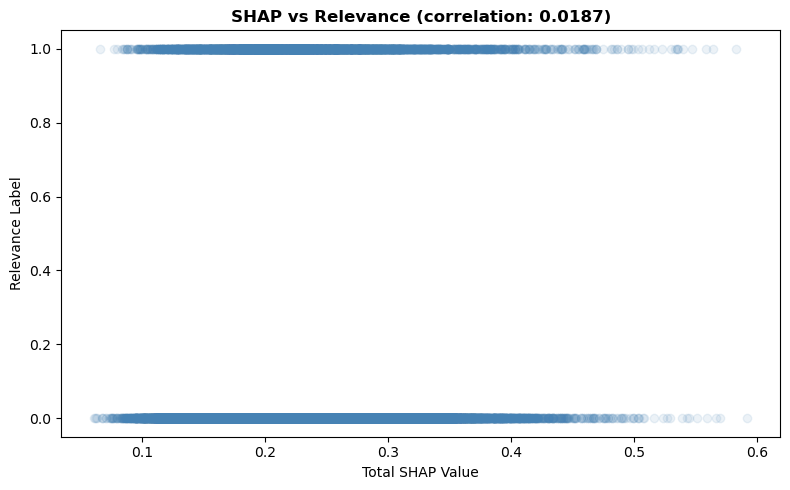

In [13]:
# SHAP Correlation with Relevance
shap_sum = np.abs(shap_values).sum(1)
corr = np.corrcoef(shap_sum, labels_list)[0,1]

plt.figure(figsize=(8, 5))
plt.scatter(shap_sum, labels_list, alpha=0.1, color='steelblue')
plt.xlabel("Total SHAP Value")
plt.ylabel("Relevance Label")
plt.title(f"SHAP vs Relevance (correlation: {corr:.4f})", fontweight='bold')
plt.tight_layout()
plt.savefig("./data/shap_correlation.png", dpi=150)
plt.show()

In [14]:
# Save HTML Report
import shap

html = shap.force_plot(
    explainer.expected_value,
    shap_values[:100],
    feature_names=feature_names
)

shap.save_html("./data/shap_report.html", html)
print("Interactive HTML report saved!")

Interactive HTML report saved!


In [15]:
# Save SHAP Values
np.save("./data/shap_values.npy", shap_values)
json.dump({
    "expected_value": float(explainer.expected_value),
    "feature_names": feature_names,
    "top_features": ['overlap', 'first_pos', 'tfidf_cosine', 'char_sim', 'avg_pos']
}, open("./data/shap_summary.json", "w"))

print(f"SHAP values saved! Shape: {shap_values.shape}")

SHAP values saved! Shape: (39962, 23)
